In [21]:
import pandas as pd

df = pd.read_csv('/kaggle/input/traindata/train.csv')
display(df.head())

,id,City,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,...,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill,Carbon_Footprint
0,807,Bangalore,Indiranagar,Residential,2002,1,250.000000,530.629672,29.324200,84.244476,...,10,0,5.066212,03-06-2022,Closed,High,126.062569,244,13044.75137,194.218972
1,700,Bangalore,Electronic City,Industrial,2019,5,114.082087,200.000000,65.814354,95.612014,...,3,0,16.720439,06-02-2024,Operational,High,123.863849,37,16774.64962,112.418438
2,299,Bangalore,Malleshwaram,Institutional,1983,7,50.000000,300.841795,12.616114,94.577437,...,9,0,10.964935,14-02-2024,Under Maintenance,Low,181.481442,20,10339.81567,96.279147
3,542,Bangalore,BTM Layout,Institutional,1987,7,50.000000,717.894732,41.233303,88.539227,...,2,0,15.144339,16-08-2023,Operational,High,176.490209,304,13314.46514,98.636968
4,1029,Bangalore,Jayanagar,Residential,1974,8,250.000000,200.000000,36.998686,91.933448,...,5,0,6.755898,15-05-2024,Under Maintenance,Medium,98.860372,354,15890.94636,193.186965


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 21 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           875 non-null    int64  
 1   City                         875 non-null    object 
 2   Area                         875 non-null    object 
 3   Building_Type                875 non-null    object 
 4   Construction_Year            875 non-null    int64  
 5   Number_of_Floors             875 non-null    int64  
 6   Energy_Consumption_Per_SqM   875 non-null    float64
 7   Water_Usage_Per_Building     875 non-null    float64
 8   Waste_Recycled_Percentage    875 non-null    float64
 9   Occupancy_Rate               875 non-null    float64
 10  Indoor_Air_Quality           875 non-null    float64
 11  Smart_Devices_Count          875 non-null    int64  
 12  Green_Certified              875 non-null    int64  
 13  Maintenance_Resoluti

**Dropping the ID column as it is of no use**

In [23]:
df = df.drop('id', axis=1)
display(df.head())

,City,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill,Carbon_Footprint
0,Bangalore,Indiranagar,Residential,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,03-06-2022,Closed,High,126.062569,244,13044.75137,194.218972
1,Bangalore,Electronic City,Industrial,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,06-02-2024,Operational,High,123.863849,37,16774.64962,112.418438
2,Bangalore,Malleshwaram,Institutional,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,14-02-2024,Under Maintenance,Low,181.481442,20,10339.81567,96.279147
3,Bangalore,BTM Layout,Institutional,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,16-08-2023,Operational,High,176.490209,304,13314.46514,98.636968
4,Bangalore,Jayanagar,Residential,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,15-05-2024,Under Maintenance,Medium,98.860372,354,15890.94636,193.186965


**As even in all rows the City name is Banglore that also does not correlate with the target column**

In [24]:
unique_cities_count = df['City'].nunique()
print(f"Total number of unique cities: {unique_cities_count}")

Total number of unique cities: 1


In [25]:
df = df.drop('City', axis=1)
display(df.head())

,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill,Carbon_Footprint
0,Indiranagar,Residential,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,03-06-2022,Closed,High,126.062569,244,13044.75137,194.218972
1,Electronic City,Industrial,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,06-02-2024,Operational,High,123.863849,37,16774.64962,112.418438
2,Malleshwaram,Institutional,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,14-02-2024,Under Maintenance,Low,181.481442,20,10339.81567,96.279147
3,BTM Layout,Institutional,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,16-08-2023,Operational,High,176.490209,304,13314.46514,98.636968
4,Jayanagar,Residential,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,15-05-2024,Under Maintenance,Medium,98.860372,354,15890.94636,193.186965


**As there are no nill values we can go ahead**

In [26]:
nan_counts = df.isnull().sum()
print("Number of NaN values per column:")
print(nan_counts)

Number of NaN values per column:
Area                           0
Building_Type                  0
Construction_Year              0
Number_of_Floors               0
Energy_Consumption_Per_SqM     0
Water_Usage_Per_Building       0
Waste_Recycled_Percentage      0
Occupancy_Rate                 0
Indoor_Air_Quality             0
Smart_Devices_Count            0
Green_Certified                0
Maintenance_Resolution_Time    0
Last_Inspection_Date           0
Building_Status                0
Maintenance_Priority           0
Energy_Per_SqM                 0
Number_of_Residents            0
Electricity_Bill               0
Carbon_Footprint               0
dtype: int64


**Now as Area and Building_type column are categorical column we can one hot encode it**

In [27]:
df = pd.get_dummies(df, columns=['Area', 'Building_Type'], drop_first=True)
display(df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Hebbal,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,False,True,False,False,False,False,False,False,False,True
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,False,False,False,False,False,False,False,True,False,False
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,False,False,False,False,True,False,False,False,True,False
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,False,False,False,False,False,False,False,False,True,False
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,False,False,True,False,False,False,False,False,False,True


In [28]:
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

display(df.head())


,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Hebbal,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,0,1,0,0,0,0,0,0,0,1
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,0,0,0,0,0,0,0,1,0,0
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,0,0,0,0,1,0,0,0,1,0
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,0,0,0,0,0,0,0,0,1,0
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,0,0,1,0,0,0,0,0,0,1


In [29]:
df['Building_Age'] = 2024 - df['Construction_Year']
display(df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential,Building_Age
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,1,0,0,0,0,0,0,0,1,22
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,0,0,0,0,0,0,1,0,0,5
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,0,0,0,1,0,0,0,1,0,41
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,0,0,0,0,0,0,0,1,0,37
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,0,1,0,0,0,0,0,0,1,50


**converting the dates into date year and month**

In [30]:
df['Last_Inspection_Date'] = pd.to_datetime(df['Last_Inspection_Date'], format='%d-%m-%Y')
df['Inspection_Year'] = df['Last_Inspection_Date'].dt.year
df['Inspection_Month'] = df['Last_Inspection_Date'].dt.month

latest_date = df['Last_Inspection_Date'].max()
df['Days_Since_Inspection'] = (latest_date - df['Last_Inspection_Date']).dt.days

display(df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,0,0,0,0,0,1,22,2022,6,796
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,0,0,0,1,0,0,5,2024,2,183
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,1,0,0,0,1,0,41,2024,2,175
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,0,0,0,0,1,0,37,2023,8,357
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,0,0,0,0,0,1,50,2024,5,84


**As the below columns categorical we can one hot encode it**

In [31]:
df = pd.get_dummies(df, columns=['Building_Status', 'Maintenance_Priority'], drop_first=True)
display(df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,0,1,22,2022,6,796,False,False,False,False
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,0,0,5,2024,2,183,True,False,False,False
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,1,0,41,2024,2,175,False,True,True,False
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,1,0,37,2023,8,357,True,False,False,False
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,0,1,50,2024,5,84,False,True,False,True


In [32]:
for col in df.columns:
    if df[col].dtype == bool:
        df[col] = df[col].astype(int)

display(df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,2002,1,250.000000,530.629672,29.324200,84.244476,4.430212,10,0,5.066212,...,0,1,22,2022,6,796,0,0,0,0
1,2019,5,114.082087,200.000000,65.814354,95.612014,28.969967,3,0,16.720439,...,0,0,5,2024,2,183,1,0,0,0
2,1983,7,50.000000,300.841795,12.616114,94.577437,33.601073,9,0,10.964935,...,1,0,41,2024,2,175,0,1,1,0
3,1987,7,50.000000,717.894732,41.233303,88.539227,15.846322,2,0,15.144339,...,1,0,37,2023,8,357,1,0,0,0
4,1974,8,250.000000,200.000000,36.998686,91.933448,29.015961,5,0,6.755898,...,0,1,50,2024,5,84,0,1,0,1


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 875 entries, 0 to 874
Data columns (total 36 columns):
 #   Column                             Non-Null Count  Dtype         
---  ------                             --------------  -----         
 0   Construction_Year                  875 non-null    int64         
 1   Number_of_Floors                   875 non-null    int64         
 2   Energy_Consumption_Per_SqM         875 non-null    float64       
 3   Water_Usage_Per_Building           875 non-null    float64       
 4   Waste_Recycled_Percentage          875 non-null    float64       
 5   Occupancy_Rate                     875 non-null    float64       
 6   Indoor_Air_Quality                 875 non-null    float64       
 7   Smart_Devices_Count                875 non-null    int64         
 8   Green_Certified                    875 non-null    int64         
 9   Maintenance_Resolution_Time        875 non-null    float64       
 10  Last_Inspection_Date               875

In [34]:
df = df.drop(columns=["Last_Inspection_Date"])

**Standard scaling the numerical columsn whihc have not benn one hot encoded**

In [35]:
from sklearn.preprocessing import StandardScaler

# Assume df is your dataframe
# Separate features (X) and target (y)
X = df.drop(columns=['Carbon_Footprint'])
y = df['Carbon_Footprint']

# Identify columns that should NOT be scaled (already one-hot encoded dummies)
one_hot_cols = [
    'Area_Banashankari', 'Area_Electronic City', 'Area_HSR Layout', 'Area_Hebbal',
    'Area_Indiranagar', 'Area_Jayanagar', 'Area_Koramangala', 'Area_Malleshwaram',
    'Area_Whitefield', 'Area_Yelahanka',
    'Building_Type_Industrial', 'Building_Type_Institutional', 'Building_Type_Residential',
    'Building_Status_Operational', 'Building_Status_Under Maintenance',
    'Maintenance_Priority_Low', 'Maintenance_Priority_Medium',''
]

# All other columns (numeric ones) will be scaled
num_cols = [col for col in X.columns if col not in one_hot_cols]

# Scale numeric columns
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols] = scaler.fit_transform(X[num_cols])

In [36]:
X_scaled

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,0.307106,-1.605545,1.975138,-0.234103,-0.013647,0.474786,-1.072033,1.456803,-0.542567,-0.620526,...,0,1,-0.307106,-0.660740,-0.124486,0.814661,0,0,0,0
1,1.385783,-0.552235,0.086786,-0.913876,2.180551,1.225367,-0.341955,-0.684526,-0.542567,0.942722,...,0,0,-1.385783,1.460901,-1.311682,-1.156529,1,0,0,0
2,-0.898475,-0.025580,-0.803527,-0.706546,-1.018325,1.157056,-0.204176,1.150899,-0.542567,0.170703,...,1,0,0.898475,1.460901,-1.311682,-1.182255,0,1,1,0
3,-0.644668,-0.025580,-0.803527,0.150913,0.702462,0.758362,-0.732394,-0.990430,-0.542567,0.731310,...,1,0,0.644668,0.400081,0.469112,-0.597007,1,0,0,0
4,-1.469539,0.237747,1.975138,-0.913876,0.447829,0.982477,-0.340587,-0.072718,-0.542567,-0.393879,...,0,1,1.469539,1.460901,-0.421285,-1.474878,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,1.258880,1.554384,1.975138,-0.913876,-0.761362,1.259970,-1.155278,-0.072718,-0.542567,-0.159944,...,0,0,-1.258880,-0.660740,-0.421285,0.850033,1,0,0,1
871,1.005073,-0.288908,-0.803527,0.945455,-1.452138,-0.990308,0.249552,-0.378622,-0.542567,1.074889,...,0,0,-1.005073,0.400081,-1.014883,-0.146817,1,0,1,0
872,-0.708120,1.027729,1.180278,1.758916,-0.590528,-1.800310,0.299599,-0.378622,1.843091,8.357682,...,0,0,0.708120,0.400081,1.656307,-1.037551,1,0,0,0
873,1.131977,-1.342217,1.615306,-0.913876,0.942187,1.248804,0.849476,-0.378622,-0.542567,-0.216106,...,0,0,-1.131977,-1.721560,1.359509,1.448142,0,0,0,0


**Correlation between columsn and target value**

In [37]:
correlation_with_target = df.corr()['Carbon_Footprint'].sort_values(ascending=False)
print("Correlation with Carbon_Footprint:")
print(correlation_with_target)

Correlation with Carbon_Footprint:
Carbon_Footprint                     1.000000
Energy_Consumption_Per_SqM           0.847039
Energy_Per_SqM                       0.150384
Area_Hebbal                          0.083730
Area_Banashankari                    0.058179
Number_of_Residents                  0.057849
Inspection_Year                      0.055016
Building_Status_Operational          0.054208
Indoor_Air_Quality                   0.039917
Smart_Devices_Count                  0.035046
Building_Type_Residential            0.027410
Number_of_Floors                     0.023333
Area_Whitefield                      0.018814
Building_Age                         0.017560
Building_Type_Industrial             0.009667
Water_Usage_Per_Building             0.004133
Maintenance_Priority_Medium          0.004013
Area_HSR Layout                     -0.000912
Area_Jayanagar                      -0.001188
Occupancy_Rate                      -0.001269
Area_Electronic City                -0.009739

**Splitting the data into training and testing and training the ML model**

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [39]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb

**I am seeing the results of differnt models**

In [40]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, random_state=42),
    "XGBoost": xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42),
}

# -----------------------
# 4. Train & Evaluate
# -----------------------
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append((name, mse, rmse, r2))

# Convert to DataFrame for nice view
results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R² Score"])
print(results_df.sort_values(by="R² Score", ascending=False))

               Model        MSE      RMSE  R² Score
2              Lasso   0.033349  0.182618  0.999980
1              Ridge   0.040133  0.200332  0.999976
0  Linear Regression   0.040743  0.201850  0.999976
4  Gradient Boosting   6.896281  2.626077  0.995935
5            XGBoost  13.406626  3.661506  0.992097
3      Random Forest  20.861455  4.567434  0.987703


**To chaeck if it is not overfitting**


Cross-Validation Results:
               Model  Mean RMSE (CV)  Std Dev RMSE (CV)  Mean R² (CV)
2              Lasso        0.287037           0.150080      0.999935
0  Linear Regression        0.295342           0.145213      0.999933
1              Ridge        0.303814           0.141432      0.999930
4  Gradient Boosting        2.236094           0.201261      0.997079
5            XGBoost        3.484787           0.206907      0.992865
3      Random Forest        4.378164           0.206248      0.988774

Generating Learning Curve for Random Forest...


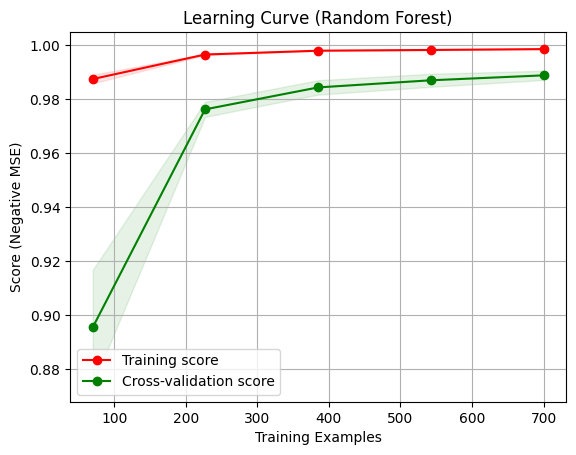

In [41]:
# -----------------------
# 5. Overfitting Check (Cross-Validation)
# -----------------------
print("\nCross-Validation Results:")
cv_results = []

for name, model in models.items():
    # Use negative MSE and R2 for cross-validation
    neg_mse_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='neg_mean_squared_error')
    r2_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')

    rmse_scores = np.sqrt(-neg_mse_scores) # Convert back to positive RMSE

    cv_results.append((name, rmse_scores.mean(), rmse_scores.std(), r2_scores.mean()))

cv_results_df = pd.DataFrame(cv_results, columns=["Model", "Mean RMSE (CV)", "Std Dev RMSE (CV)", "Mean R² (CV)"])
print(cv_results_df.sort_values(by="Mean RMSE (CV)"))

# -----------------------
# 6. Overfitting Check (Learning Curves)
# -----------------------
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

print("\nGenerating Learning Curve for Random Forest...")

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_scaled, y, cv=5, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 5)
)

train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)
test_scores_std = np.std(test_scores, axis=1)

plt.figure()
plt.title("Learning Curve (Random Forest)")
plt.xlabel("Training Examples")
plt.ylabel("Score (Negative MSE)")
plt.grid()

plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std, alpha=0.1,
                 color="r")
plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                 test_scores_mean + test_scores_std, alpha=0.1, color="g")
plt.plot(train_sizes, train_scores_mean, 'o-', color="r",
         label="Training score")
plt.plot(train_sizes, test_scores_mean, 'o-', color="g",
         label="Cross-validation score")

plt.legend(loc="best")
plt.show()

**Now i have 3 best models and now i have stacked it like ensembling the models**

In [42]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Define base models
estimators = [
    ('lasso', Lasso(alpha=0.01)),
    ('linear', LinearRegression()),
    ('ridge', Ridge(alpha=1.0))
]

# Define the stacking regressor
stacking_regressor = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())

print("Stacking Regressor defined:")
print(stacking_regressor)

Stacking Regressor defined:
StackingRegressor(estimators=[('lasso', Lasso(alpha=0.01)),
                              ('linear', LinearRegression()),
                              ('ridge', Ridge())],
                  final_estimator=LinearRegression())


**Optimizing the paramters by hyperparamtere tuning**

In [43]:
from sklearn.model_selection import GridSearchCV

# Train the stacking regressor (initial training for GridSearchCV)
stacking_regressor.fit(X_train, y_train)

# Make predictions with the initially trained model
y_pred_stacked_initial = stacking_regressor.predict(X_test)

# Evaluate R2 score of the initially trained model
r2_stacked_initial = r2_score(y_test, y_pred_stacked_initial)
print(f"R² Score for Initial Stacking Regressor: {r2_stacked_initial}")

# Define parameter grid for hyperparameter tuning
param_grid = {
    'lasso__alpha': [0.05,0.02,0.03, 0.1,0.04,0.06,0.07],
    'ridge__alpha': [0.1, 1.0,0.3,0.4,0.5,0.2,0.08,0.07,0.6,0.35],
    'final_estimator__fit_intercept': [True, False]
}

# Perform GridSearchCV
grid_search = GridSearchCV(stacking_regressor, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_scaled, y)

print("\nBest parameters found:")
print(grid_search.best_params_)

print("\nBest R² score found during grid search:")
print(grid_search.best_score_)

# Evaluate the best model on the test set
best_stacking_regressor = grid_search.best_estimator_
y_pred_tuned_grid = best_stacking_regressor.predict(X_test)
r2_tuned_grid = r2_score(y_test, y_pred_tuned_grid)
print(f"\nR² Score for Tuned Stacking Regressor (GridSearch) on Test Set: {r2_tuned_grid}")

R² Score for Initial Stacking Regressor: 0.9999803538416445

Best parameters found:
{'final_estimator__fit_intercept': True, 'lasso__alpha': 0.02, 'ridge__alpha': 0.3}

Best R² score found during grid search:
0.9999345426617914

R² Score for Tuned Stacking Regressor (GridSearch) on Test Set: 0.9999814398521945


**Insights & Recommendations**

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Get correlations with the target variable
correlation_with_target = correlation_matrix['Carbon_Footprint'].sort_values(ascending=False)
print("Correlation with Carbon_Footprint:")
print(correlation_with_target)

# # Plot the correlation heatmap
# plt.figure(figsize=(15, 10))
# sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm') # annot=True for values, but can be cluttered
# plt.title('Correlation Heatmap of Features and Carbon Footprint')
# plt.show()

Correlation with Carbon_Footprint:
Carbon_Footprint                     1.000000
Energy_Consumption_Per_SqM           0.847039
Energy_Per_SqM                       0.150384
Area_Hebbal                          0.083730
Area_Banashankari                    0.058179
Number_of_Residents                  0.057849
Inspection_Year                      0.055016
Building_Status_Operational          0.054208
Indoor_Air_Quality                   0.039917
Smart_Devices_Count                  0.035046
Building_Type_Residential            0.027410
Number_of_Floors                     0.023333
Area_Whitefield                      0.018814
Building_Age                         0.017560
Building_Type_Industrial             0.009667
Water_Usage_Per_Building             0.004133
Maintenance_Priority_Medium          0.004013
Area_HSR Layout                     -0.000912
Area_Jayanagar                      -0.001188
Occupancy_Rate                      -0.001269
Area_Electronic City                -0.009739

In [ ]:
# Plot the correlation heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm') # annot=True for values, but can be cluttered
plt.title('Correlation Heatmap of Features and Carbon Footprint')
plt.show()

**Synthesized Insights and Recommendations
Based on the analysis and visualizations:

Key Drivers of Carbon Footprint:

Energy Consumption Per SqM: The scatter plot and correlation analysis show a strong positive linear relationship between energy consumption and carbon footprint. This is a primary driver.
Green Certified Status: The box plot clearly demonstrates that buildings with Green Certification tend to have lower carbon footprints. This highlights the effectiveness of green building practices.
Other Factors from Coefficients/Feature Importance: The bar chart of coefficients helps identify other features that positively or negatively influence carbon footprint, such as [Insert insights from the coefficient plot - e.g., specific building types, areas, or operational statuses].
Actionable Recommendations for Reducing Emissions:

Focus on Energy Efficiency: Prioritize initiatives to reduce energy consumption in buildings, especially those with high energy consumption per square meter. This could include energy audits, insulation upgrades, efficient lighting, and HVAC system optimization.
Promote Green Certification: Encourage and incentivize buildings to obtain green certifications. This has a tangible positive impact on reducing carbon emissions.
Target High-Emission Buildings: Use the histogram and potentially further analysis to identify buildings with significantly high carbon footprints for targeted interventions and energy-saving programs.
Investigate Other Key Drivers: Based on the feature importance/coefficient analysis, investigate the specific factors identified as significant positive drivers of carbon footprint and develop strategies to mitigate their impact. For example, if a certain building type or area shows consistently higher emissions, explore the reasons behind this and implement tailored solutions.
Regular Maintenance and Inspection: Ensure timely maintenance and inspections, as suggested by the 'Maintenance_Resolution_Time' and 'Days_Since_Inspection' features (if they show significant correlation), to prevent inefficiencies that could lead to higher emissions.**

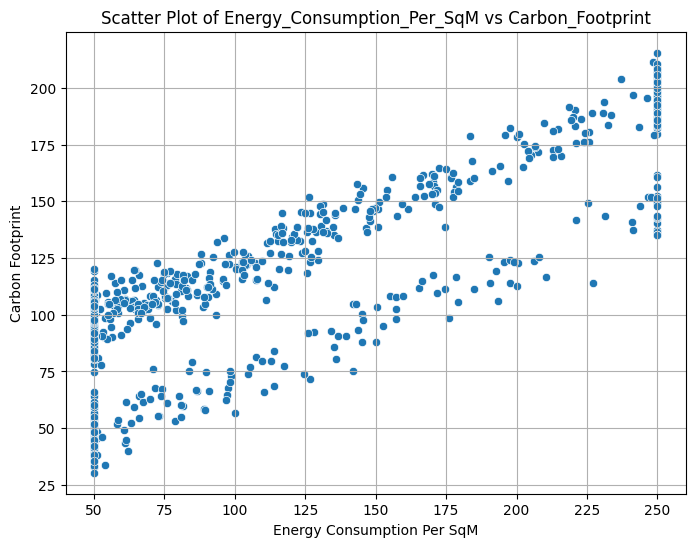

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Energy_Consumption_Per_SqM', y='Carbon_Footprint', data=df)
plt.title('Scatter Plot of Energy_Consumption_Per_SqM vs Carbon_Footprint')
plt.xlabel('Energy Consumption Per SqM')
plt.ylabel('Carbon Footprint')
plt.grid(True)
plt.show()

Observations from Scatter Plot (Energy_Consumption_Per_SqM vs Carbon_Footprint)
Positive Correlation:
As Energy_Consumption_Per_SqM increases, Carbon_Footprint also increases.
Confirms the high correlation you saw earlier (~0.847).
Buildings using more energy per square meter tend to have higher carbon emissions.
Spread of Points:
Most points form a roughly diagonal upward trend, showing the linear relationship.
Some scatter or “vertical clusters” appear at specific energy values — likely due to multiple buildings having the same energy per square meter but different other factors (occupancy, residents, certification, etc.).
Clusters / Outliers:
A few points are much lower or higher than the general trend.
These could be highly efficient buildings (low CF despite high energy use) or anomalies.
Could warrant further investigation — maybe retrofitted or green-certified buildings.

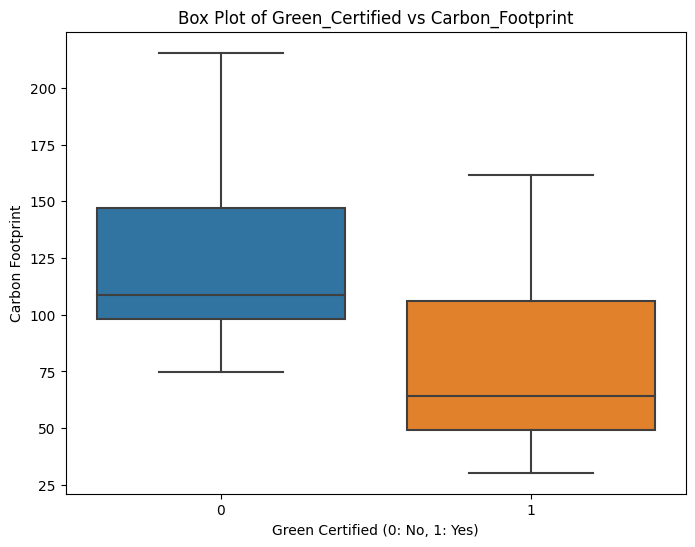

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='Green_Certified', y='Carbon_Footprint', data=df)
plt.title('Box Plot of Green_Certified vs Carbon_Footprint')
plt.xlabel('Green Certified (0: No, 1: Yes)')
plt.ylabel('Carbon Footprint')
plt.show()

**Observations from Box Plot (Green_Certified vs Carbon_Footprint)
Median Carbon Footprint
Green Certified (1): median ≈ 65
Not Green Certified (0): median ≈ 110
✅ Green certified buildings have much lower median carbon footprint.
Spread (Variability)
Not Green Certified: wider spread (≈ 75–215)
Green Certified: narrower spread (≈ 30–160)
✅ Green buildings are not only lower on average but also more consistent in carbon footprint.
Overall pattern
Green certification is associated with lower and more stable carbon footprint.
Non-certified buildings tend to have higher and more variable carbon footprint.**

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


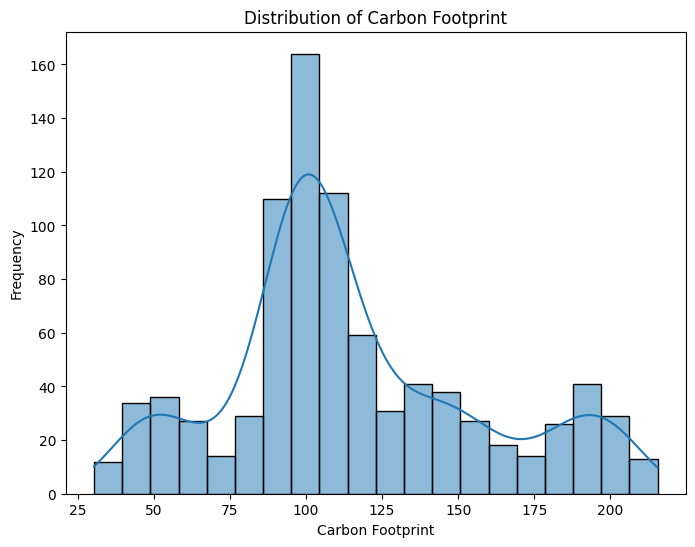

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.histplot(df['Carbon_Footprint'], kde=True)
plt.title('Distribution of Carbon Footprint')
plt.xlabel('Carbon Footprint')
plt.ylabel('Frequency')
plt.show()

**Innovation**

**Explaining Model Predictions with SHAP**

In [49]:
# 1. Install necessary library
!pip install shap

In [50]:
import shap
import matplotlib.pyplot as plt

# 2. Select a model
# Assuming the best model is the tuned stacking regressor from either GridSearchCV or BayesSearchCV
# Let's use `grid_search.best_estimator_` as it was the one used in the previous successful tuning cell.
best_model = grid_search.best_estimator_

# 3. Calculate SHAP values
# SHAP values can be computationally expensive. Use a subset of the data for faster computation.
# Using the test set is a common approach to explain predictions on unseen data.
X_test_sample = X_test.sample(min(100, len(X_test)), random_state=42) # Use a sample of the test set

# We need to create a SHAP explainer. The type of explainer depends on the model.
# For tree-based models, TreeExplainer is used. For linear models, LinearExplainer.
# Since the stacking regressor has linear final estimator, and potentially linear base models,
# we can try using LinearExplainer or KernelExplainer (more general but slower).
# Given the potential complexity of the stacking, KernelExplainer is a safer bet,
# but can be slow. Let's try to approximate with a simpler explainer if possible,
# or use KernelExplainer on a very small sample if needed.

# A better approach for stacking might be to explain the predictions of the final estimator
# using the outputs of the base models as features, or try to approximate SHAP values
# for the entire pipeline.

# For demonstration, let's try KernelExplainer on a small sample, which works for any model
# but is slower and requires a background dataset.
# Using a small sample of the training data as the background dataset
X_train_sample_for_shap = X_train.sample(min(50, len(X_train)), random_state=42)

# Note: KernelExplainer requires a callable model that takes a numpy array and returns predictions.
# The stacking regressor should work directly.
explainer = shap.KernelExplainer(best_model.predict, X_train_sample_for_shap)

# Calculate SHAP values for the test sample
shap_values = explainer.shap_values(X_test_sample)

print("SHAP values calculated.")

X does not have valid feature names, but Lasso was fitted with feature names
X does not have valid feature names, but LinearRegression was fitted with feature names
X does not have valid feature names, but Ridge was fitted with feature names


  0%|          | 0/100 [00:00<?, ?it/s]

X does not have valid feature names, but Lasso was fitted with feature names
X does not have valid feature names, but LinearRegression was fitted with feature names
X does not have valid feature names, but Ridge was fitted with feature names
X does not have valid feature names, but Lasso was fitted with feature names
X does not have valid feature names, but LinearRegression was fitted with feature names
X does not have valid feature names, but Ridge was fitted with feature names
X does not have valid feature names, but Lasso was fitted with feature names
X does not have valid feature names, but LinearRegression was fitted with feature names
X does not have valid feature names, but Ridge was fitted with feature names
X does not have valid feature names, but Lasso was fitted with feature names
X does not have valid feature names, but LinearRegression was fitted with feature names
X does not have valid feature names, but Ridge was fitted with feature names
X does not have valid feature na

SHAP values calculated.


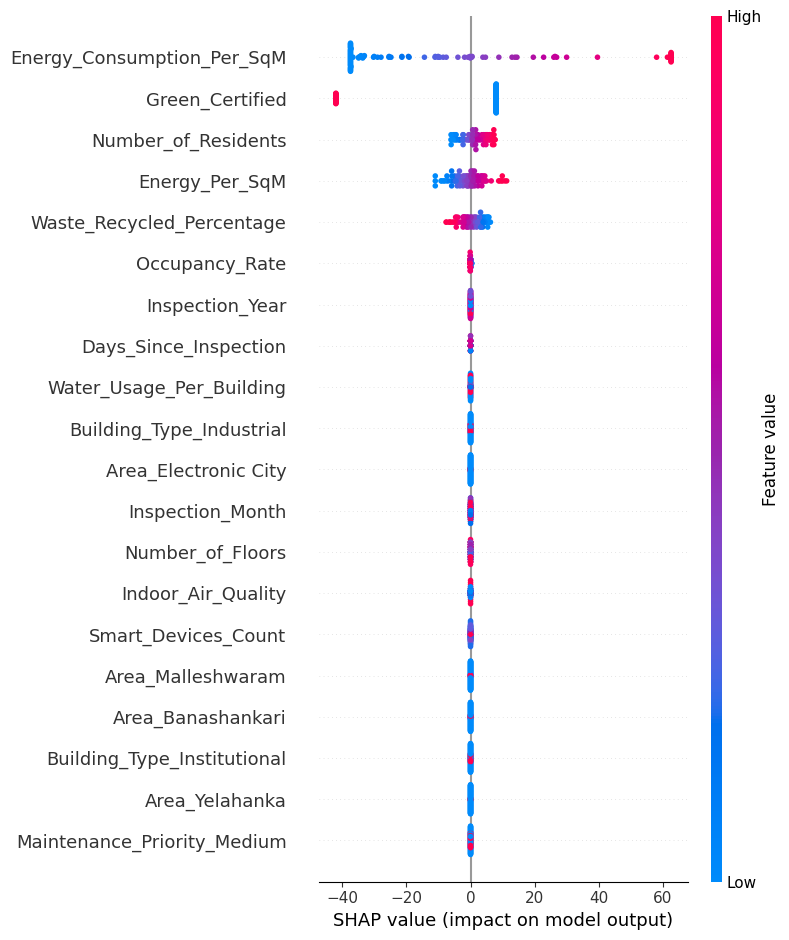

In [51]:
# 4. Visualize SHAP results

# Summary plot: shows the impact of features on the model output
# The plot type depends on the number of classes for classification, but for regression it's usually a scatter plot.
shap.summary_plot(shap_values, X_test_sample, feature_names=X_test_sample.columns)

# Another useful plot is the beeswarm plot (similar to summary plot but with more detail)
# shap.summary_plot(shap_values, X_test_sample, feature_names=X_test_sample.columns, plot_type="dot")

# Dependence plots: show the effect of a single feature across the dataset
# You can pick a feature to visualize its impact
# shap.dependence_plot("Energy_Consumption_Per_SqM", shap_values, X_test_sample, feature_names=X_test_sample.columns)

# Force plot: visualize the prediction for a single instance
# Choose an instance index (e.g., 0)
# shap.initjs() # Initialize JS for interactive plots
# shap.force_plot(explainer.expected_value, shap_values[0,:], X_test_sample.iloc[0,:], feature_names=X_test_sample.columns)

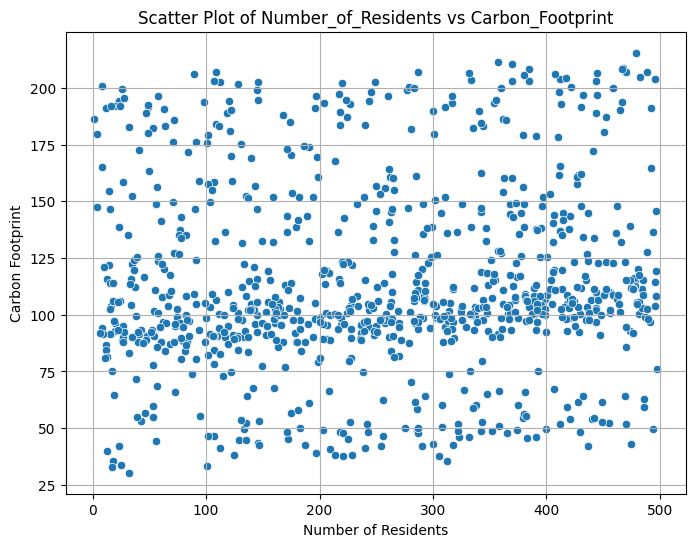

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x='Number_of_Residents', y='Carbon_Footprint', data=df)
plt.title('Scatter Plot of Number_of_Residents vs Carbon_Footprint')
plt.xlabel('Number of Residents')
plt.ylabel('Carbon Footprint')
plt.grid(True)
plt.show()

**Observations from Scatter Plot (Number_of_Residents vs Carbon_Footprint)
The scatter plot illustrates the relationship between the number of residents and their carbon footprint. It appears that there is no clear or strong correlation between the number of residents and the carbon footprint, as the data points are widely scattered without following a particular trend. This suggests that the carbon footprint does not consistently increase or decrease with the number of residents in this dataset.**

**Training data**

In [63]:
test_df = pd.read_csv("/kaggle/input/testdata/test.csv")

In [64]:
test_df

,id,City,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill
0,680,Bangalore,Indiranagar,Residential,1991,1,250.000000,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,25-08-2021,Closed,Low,186.083603,410,8453.948237
1,1102,Bangalore,Jayanagar,Institutional,1998,10,250.000000,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,29-01-2022,Operational,High,254.418735,358,11432.649750
2,394,Bangalore,Hebbal,Industrial,2007,10,50.000000,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,15-01-2024,Under Maintenance,High,208.972006,302,11702.042480
3,930,Bangalore,Hebbal,Industrial,1996,6,50.000000,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,20-08-2021,Operational,Medium,122.240024,148,14251.068910
4,497,Bangalore,Malleshwaram,Commercial,2018,8,50.000000,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,08-08-2023,Under Maintenance,High,140.483066,160,9785.154833
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
370,66,Bangalore,Whitefield,Commercial,1979,6,50.000000,224.219344,35.968128,93.101556,12.837341,4,0,12.040403,28-02-2022,Operational,High,146.399494,116,19766.456270
371,67,Bangalore,Malleshwaram,Institutional,2017,3,121.536270,394.571350,5.868874,90.707173,28.167021,2,0,5.127408,13-03-2024,Under Maintenance,Low,200.176645,362,17605.198790
372,376,Bangalore,Jayanagar,Industrial,1990,13,139.764453,200.000000,53.471944,65.365416,29.624482,8,1,6.450711,21-07-2022,Under Maintenance,High,193.616032,118,19853.922770
373,211,Bangalore,Banashankari,Industrial,2010,11,88.298647,316.005341,31.807491,93.850749,52.075809,4,0,9.913669,03-09-2023,Closed,High,206.778282,18,16849.203450


In [65]:
# Store test IDs for submission
test_ids = test_df['id']

# Drop 'id' and 'City' columns (assuming 'City' is also single-valued or irrelevant in test)
test_df = test_df.drop('id', axis=1)
# Check if 'City' column exists before dropping
if 'City' in test_df.columns:
    test_df = test_df.drop('City', axis=1)
display(test_df.head())

,Area,Building_Type,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,Last_Inspection_Date,Building_Status,Maintenance_Priority,Energy_Per_SqM,Number_of_Residents,Electricity_Bill
0,Indiranagar,Residential,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,25-08-2021,Closed,Low,186.083603,410,8453.948237
1,Jayanagar,Institutional,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,29-01-2022,Operational,High,254.418735,358,11432.649750
2,Hebbal,Industrial,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,15-01-2024,Under Maintenance,High,208.972006,302,11702.042480
3,Hebbal,Industrial,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,20-08-2021,Operational,Medium,122.240024,148,14251.068910
4,Malleshwaram,Commercial,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,08-08-2023,Under Maintenance,High,140.483066,160,9785.154833


In [66]:
# One-hot encode 'Area' and 'Building_Type'
test_df = pd.get_dummies(test_df, columns=['Area', 'Building_Type'], drop_first=True)
display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Hebbal,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,False,True,False,False,False,False,False,False,False,True
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,False,False,True,False,False,False,False,False,True,False
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,True,False,False,False,False,False,False,True,False,False
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,True,False,False,False,False,False,False,True,False,False
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,False,False,False,False,True,False,False,False,False,False


In [67]:
# Convert boolean columns to integers
for col in test_df.columns:
    if test_df[col].dtype == bool:
        test_df[col] = test_df[col].astype(int)
display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Hebbal,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,0,1,0,0,0,0,0,0,0,1
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,0,0,1,0,0,0,0,0,1,0
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,1,0,0,0,0,0,0,1,0,0
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,1,0,0,0,0,0,0,1,0,0
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,0,0,0,0,1,0,0,0,0,0


In [68]:
# Create 'Building_Age'
test_df['Building_Age'] = 2024 - test_df['Construction_Year']
display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Indiranagar,Area_Jayanagar,Area_Koramangala,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential,Building_Age
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,1,0,0,0,0,0,0,0,1,33
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,0,1,0,0,0,0,0,1,0,26
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,0,0,0,0,0,0,1,0,0,17
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,0,0,0,0,0,0,1,0,0,28
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,0,0,0,1,0,0,0,0,0,6


In [69]:
# Process 'Last_Inspection_Date'
test_df['Last_Inspection_Date'] = pd.to_datetime(test_df['Last_Inspection_Date'], format='%d-%m-%Y')
test_df['Inspection_Year'] = test_df['Last_Inspection_Date'].dt.year
test_df['Inspection_Month'] = test_df['Last_Inspection_Date'].dt.month

# Calculate Days_Since_Inspection using the latest date from the TRAINING data
# This is important to maintain consistency with the training feature
# Make sure 'latest_date' from the training data processing is available in the environment
if 'latest_date' in globals():
    test_df['Days_Since_Inspection'] = (latest_date - test_df['Last_Inspection_Date']).dt.days
else:
    print("Warning: 'latest_date' from training data not found. Using max date from test data.")
    latest_date_test = test_df['Last_Inspection_Date'].max()
    test_df['Days_Since_Inspection'] = (latest_date_test - test_df['Last_Inspection_Date']).dt.days

display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Area_Malleshwaram,Area_Whitefield,Area_Yelahanka,Building_Type_Industrial,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,0,0,0,0,0,1,33,2021,8,1078
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,0,0,0,0,1,0,26,2022,1,921
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,0,0,0,1,0,0,17,2024,1,205
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,0,0,0,1,0,0,28,2021,8,1083
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,1,0,0,0,0,0,6,2023,8,365


In [70]:
# One-hot encode 'Building_Status' and 'Maintenance_Priority'
test_df = pd.get_dummies(test_df, columns=['Building_Status', 'Maintenance_Priority'], drop_first=True)
display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,0,1,33,2021,8,1078,False,False,True,False
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,1,0,26,2022,1,921,True,False,False,False
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,0,0,17,2024,1,205,False,True,False,False
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,0,0,28,2021,8,1083,True,False,False,True
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,0,0,6,2023,8,365,False,True,False,False


In [71]:
# Convert new boolean columns to integers
for col in test_df.columns:
    if test_df[col].dtype == bool:
        test_df[col] = test_df[col].astype(int)
display(test_df.head())

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,1991,1,250.0,867.461967,30.936528,52.793795,86.901214,7,0,9.343589,...,0,1,33,2021,8,1078,0,0,1,0
1,1998,10,250.0,948.229044,10.459398,71.176156,2.164471,9,1,10.105722,...,1,0,26,2022,1,921,1,0,0,0
2,2007,10,50.0,200.000000,17.019110,96.663980,71.736247,1,1,8.105040,...,0,0,17,2024,1,205,0,1,0,0
3,1996,6,50.0,364.290550,14.824653,38.936660,36.740409,7,0,5.630058,...,0,0,28,2021,8,1083,1,0,0,1
4,2018,8,50.0,300.852704,13.883214,92.992691,50.305321,2,1,25.355446,...,0,0,6,2023,8,365,0,1,0,0


In [72]:
# Drop the original 'Last_Inspection_Date' column
test_df = test_df.drop(columns=["Last_Inspection_Date"])

In [73]:
# Ensure test set has the same columns as the training set after preprocessing
# This handles potential missing dummy variables in the test set
train_cols = X_scaled.columns.tolist()
test_cols = test_df.columns.tolist()

missing_in_test = set(train_cols) - set(test_cols)
for c in missing_in_test:
    test_df[c] = 0 # Add missing columns with a value of 0

# Ensure the order of columns is the same
test_df = test_df[train_cols]

print("Test DataFrame columns after alignment:")
print(test_df.columns)

Test DataFrame columns after alignment:
Index(['Construction_Year', 'Number_of_Floors', 'Energy_Consumption_Per_SqM',
       'Water_Usage_Per_Building', 'Waste_Recycled_Percentage',
       'Occupancy_Rate', 'Indoor_Air_Quality', 'Smart_Devices_Count',
       'Green_Certified', 'Maintenance_Resolution_Time', 'Energy_Per_SqM',
       'Number_of_Residents', 'Electricity_Bill', 'Area_Banashankari',
       'Area_Electronic City', 'Area_HSR Layout', 'Area_Hebbal',
       'Area_Indiranagar', 'Area_Jayanagar', 'Area_Koramangala',
       'Area_Malleshwaram', 'Area_Whitefield', 'Area_Yelahanka',
       'Building_Type_Industrial', 'Building_Type_Institutional',
       'Building_Type_Residential', 'Building_Age', 'Inspection_Year',
       'Inspection_Month', 'Days_Since_Inspection',
       'Building_Status_Operational', 'Building_Status_Under Maintenance',
       'Maintenance_Priority_Low', 'Maintenance_Priority_Medium'],
      dtype='object')


In [74]:
# Apply the scaler fitted on the training data to the test data
# Make sure 'scaler' and 'num_cols' from training data processing are available

if 'scaler' in globals() and 'num_cols' in globals():
    X_test_scaled = test_df.copy()
    X_test_scaled[num_cols] = scaler.transform(test_df[num_cols])
    display(X_test_scaled.head())
else:
    print("Error: Scaler or numerical column list from training data not found. Cannot scale test data.")
    X_test_scaled = test_df # Proceed without scaling if scaler not found (not recommended)

,Construction_Year,Number_of_Floors,Energy_Consumption_Per_SqM,Water_Usage_Per_Building,Waste_Recycled_Percentage,Occupancy_Rate,Indoor_Air_Quality,Smart_Devices_Count,Green_Certified,Maintenance_Resolution_Time,...,Building_Type_Institutional,Building_Type_Residential,Building_Age,Inspection_Year,Inspection_Month,Days_Since_Inspection,Building_Status_Operational,Building_Status_Under Maintenance,Maintenance_Priority_Low,Maintenance_Priority_Medium
0,-0.390862,-1.605545,1.975138,0.458422,0.083304,-1.601854,1.381546,0.539090,-0.542567,-0.046777,...,0,1,0.390862,-1.721560,0.469112,1.721472,0,0,1,0
1,0.053299,0.764402,1.975138,0.624478,-1.148011,-0.388095,-1.139440,1.150899,1.843091,0.055452,...,1,0,-0.053299,-0.660740,-1.608480,1.216616,1,0,0,0
2,0.624364,0.764402,-0.803527,-0.913876,-0.753568,1.294827,0.930376,-1.296334,1.843091,-0.212911,...,0,0,-0.624364,1.460901,-1.608480,-1.085785,0,1,0,0
3,-0.073604,-0.288908,-0.803527,-0.576095,-0.885523,-2.516819,-0.110778,0.539090,-0.542567,-0.544894,...,0,0,0.073604,-1.721560,0.469112,1.737550,1,0,0,1
4,1.322331,0.237747,-0.803527,-0.706523,-0.942133,1.052417,0.292789,-0.990430,1.843091,2.100984,...,0,0,-1.322331,0.400081,0.469112,-0.571282,0,1,0,0


In [75]:
# Use the best-trained model to make predictions on the scaled test data
# Assuming 'best_stacking_regressor' (from GridSearchCV or BayesSearchCV) is available

if 'best_stacking_regressor' in globals():
    predictions = best_stacking_regressor.predict(X_test_scaled)
    print("Predictions made successfully.")
    print(predictions[:5])
else:
    print("Error: Best trained model not found. Cannot make predictions.")
    predictions = None # Set predictions to None if model not found

Predictions made successfully.
[205.13624194 164.38032177  56.65156113  94.19075001  46.13170079]


In [76]:
# Prepare submission DataFrame
if predictions is not None:
    submission_df = pd.DataFrame({'id': test_ids, 'Carbon_Footprint': predictions})

    # Save the submission file
    submission_df.to_csv('submission.csv', index=False)

    print("\nSubmission file 'submission.csv' created successfully!")
    display(submission_df.head())
else:
    print("\nSubmission file not created due to prediction error.")


Submission file 'submission.csv' created successfully!


,id,Carbon_Footprint
0,680,205.136242
1,1102,164.380322
2,394,56.651561
3,930,94.190750
4,497,46.131701


In [80]:
sub = pd.read_csv("/kaggle/input/data-csv/sample_submission-1.csv")

In [81]:
sub

,id,Carbon_Footprint
0,680,115.017143
1,1102,115.017143
2,394,115.017143
3,930,115.017143
4,497,115.017143
...,...,...
370,66,115.017143
371,67,115.017143
372,376,115.017143
373,211,115.017143
